#### <h1 style="color: #ab9bde;">IMPORT LIBRARIES</h1>

In [167]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Statistics
from scipy import stats

# Date & Time
from datetime import datetime

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Warning Control
import warnings
warnings.filterwarnings('ignore')

import os
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


<div style="color:#ab9bde;">

## <h2>Load Feature engineered dataset:</h2>
</div>

In [87]:
DATA_PATH = "../data/hotel_bookings_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)

print("Feature-engineered dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Feature-engineered dataset loaded successfully.
Rows: 87,396
Columns: 58


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time_bucket,adr_bucket,total_nights,estimated_booking_value,has_invalid_adr,is_zero_night_stay,is_weekend_stay,stay_length_category,is_last_minute_booking,is_long_lead_booking,arrival_month_number,arrival_season,is_peak_season,has_previous_cancellation,has_previous_successful_booking,has_booking_changes,has_special_requests,is_waitlisted,previous_total_bookings,previous_cancellation_rate,repeat_guest_with_deposit,repeat_guest_non_refund,is_zero_adr,is_high_adr,is_high_value_booking,room_type_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,181-365 Days,0-50,0,0.00,0,1,0,Zero-night stay,0,1,7,Summer,1,0,0,1,0,0,0,0.00,0,0,1,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,365+ Days,0-50,0,0.00,0,1,0,Zero-night stay,0,1,7,Summer,1,0,0,1,0,0,0,0.00,0,0,1,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,0-30 Days,51-100,1,75.00,0,0,0,Short stay,1,0,7,Summer,1,0,0,0,0,0,0,0.00,0,0,0,0,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,0-30 Days,51-100,1,75.00,0,0,0,Short stay,0,0,7,Summer,1,0,0,0,0,0,0,0.00,0,0,0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,0-30 Days,51-100,2,196.00,0,0,0,Short stay,0,0,7,Summer,1,0,0,0,1,0,0,0.00,0,0,0,0,0,0


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 58 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   hotel                            87396 non-null  str    
 1   is_canceled                      87396 non-null  int64  
 2   lead_time                        87396 non-null  int64  
 3   arrival_date_year                87396 non-null  int64  
 4   arrival_date_month               87396 non-null  str    
 5   arrival_date_week_number         87396 non-null  int64  
 6   arrival_date_day_of_month        87396 non-null  int64  
 7   stays_in_weekend_nights          87396 non-null  int64  
 8   stays_in_week_nights             87396 non-null  int64  
 9   adults                           87396 non-null  int64  
 10  children                         87392 non-null  float64
 11  babies                           87396 non-null  int64  
 12  meal                         

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,87396.00,0.27,0.45,0.00,0.00,0.00,1.00,1.00
lead_time,87396.00,79.89,86.05,0.00,11.00,49.00,125.00,737.00
arrival_date_year,87396.00,2016.21,0.69,2015.00,2016.00,2016.00,2017.00,2017.00
arrival_date_week_number,87396.00,26.84,13.67,1.00,16.00,27.00,37.00,53.00
arrival_date_day_of_month,87396.00,15.82,8.84,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,87396.00,1.01,1.03,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,87396.00,2.63,2.05,0.00,1.00,2.00,4.00,50.00
adults,87396.00,1.88,0.63,0.00,2.00,2.00,2.00,55.00
children,87392.00,0.14,0.46,0.00,0.00,0.00,0.00,10.00
babies,87396.00,0.01,0.11,0.00,0.00,0.00,0.00,10.00


In [90]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'lead_time_bucket',
       'adr_bucket', 'total_nights', 'estimated_booking_value',
       'has_invalid_adr', 'is_zero_night_stay', 'is_weekend_stay',
       'stay_length_category', 'is_last_minute_booking',
       'is_long_lead_booking', 'arrival_month_number', 'arrival_season',
       'is_peak_season',

In [91]:
# Confirm target column
target_col = "is_canceled"

if target_col in df.columns:
    print(f"Target column `{target_col}` found.")
else:
    print(f"Target column `{target_col}` is missing.")

Target column `is_canceled` found.


In [92]:
# Check target distribution
target_distribution = (
    df[target_col]
    .value_counts()
    .reset_index()
)

target_distribution.columns = [target_col, "booking_count"]

target_distribution["percentage"] = (
    target_distribution["booking_count"] / len(df) * 100
).round(2)

target_distribution

,is_canceled,booking_count,percentage
0,0,63371,72.51
1,1,24025,27.49


 
<div style="color:#ab9bde;">

## <h2>Target Distribution Check:</h2>

- The target variable is `is_canceled`.

- This confirms whether each booking was cancelled or not cancelled.

- The target distribution will be reviewed before modeling because cancellation prediction is a classification problem with moderate class imbalance.

</div>

<div style="color:#ab9bde;">

## <h2>Define target and candidate features:</h2>
</div>

In [93]:
target_col = "is_canceled"

target_col

'is_canceled'

In [94]:
# Columns to exclude
exclude_cols = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date"
]

In [95]:
# Candidate feature
candidate_features = [
    col for col in df.columns
    if col not in exclude_cols
]

print(f"Number of candidate features: {len(candidate_features)}")
candidate_features

Number of candidate features: 55


['hotel',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'lead_time_bucket',
 'adr_bucket',
 'total_nights',
 'estimated_booking_value',
 'has_invalid_adr',
 'is_zero_night_stay',
 'is_weekend_stay',
 'stay_length_category',
 'is_last_minute_booking',
 'is_long_lead_booking',
 'arrival_month_number',
 'arrival_season',
 'is_peak_season',
 'has_previous_cancellation',
 'has_previous_successful_booking',
 'has_booking_changes',
 'has_special_requests',
 'is_waitlisted',


<div style="color:#ab9bde;">

## <h3>Leakage review:</h3>
</div>

In [96]:
leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

for col in leakage_cols:
    print(f"{col}: {col in df.columns}")

reservation_status: True
reservation_status_date: True


In [97]:
[col for col in leakage_cols if col in candidate_features]

[]

<div style="color:#ab9bde;">

## <h3>Define 'X' and 'y':</h3>
</div>

In [98]:
X = df[candidate_features].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (87396, 55)
y shape: (87396,)


<div style="color:#ab9bde;">

## <h2>Target and Leakage Review Summary:</h2>

- The target variable for this modeling task is `is_canceled`.

- The leakage-prone columns `reservation_status` and `reservation_status_date` are present in the dataset, but they have been excluded from the candidate feature set.

- This is important because these columns contain information related to the final booking outcome and would make the model unrealistically strong.

- After leakage removal, the feature matrix `X` contains **87,396 rows** and **55 candidate features**, while the target vector `y` contains **87,396 rows**.
</div>

#### <h3 style="color: #ab9bde;">Train/tes Split</h3>

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (69916, 55)
X_test shape: (17480, 55)
y_train shape: (69916,)
y_test shape: (17480,)


In [100]:
train_target_distribution = (
    y_train
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_target_distribution = (
    y_test
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Training target distribution:")
print(train_target_distribution)

print("\nTesting target distribution:")
print(test_target_distribution)

Training target distribution:
is_canceled
0   72.51
1   27.49
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0   72.51
1   27.49
Name: proportion, dtype: float64


#### <h3 style="color: #ab9bde;">Preprocessing Pipeline</h3>

In [101]:
# Feaature data types
X_train.dtypes.value_counts()

int64      35
str        14
float64     6
Name: count, dtype: int64

In [102]:
X_train.select_dtypes(include=["object"]).columns.tolist()

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'lead_time_bucket',
 'adr_bucket',
 'stay_length_category',
 'arrival_season']

In [103]:
X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'total_nights',
 'estimated_booking_value',
 'has_invalid_adr',
 'is_zero_night_stay',
 'is_weekend_stay',
 'is_last_minute_booking',
 'is_long_lead_booking',
 'arrival_month_number',
 'is_peak_season',
 'has_previous_cancellation',
 'has_previous_successful_booking',
 'has_booking_changes',
 'has_special_requests',
 'is_waitlisted',
 'previous_total_bookings',
 'previous_cancellation_rate',
 'repeat_guest_with_deposit',
 'repeat_guest_non_refund',
 'is_zero_adr',
 'is_high_adr',
 'is_high_value_booking',
 'room_type_changed']

<div style="color:#ab9bde;">



- The feature-engineered dataset contains both raw and engineered columns.

- For the first modeling version, the feature set is kept focused to avoid unnecessary overlap between raw columns and engineered features.

- Some raw columns are excluded from the first model because their information is already captured by engineered features.

</div>

#### <h3 style="color: #ab9bde;">Modeling Feature Groups</h3>

In [104]:
# Features excluded from the first modeling version due to overlap or high cardinality

model_exclude_features = [
    "arrival_date_month",      # captured by arrival_month_number, arrival_season, is_peak_season
    "country",                 # high-cardinality feature; can be revisited later
    "reserved_room_type",      # captured partially by room_type_changed
    "assigned_room_type",      # captured partially by room_type_changed
    "meal",                    # optional; can be revisited later
    "agent",                   # ID-like column, not a true numeric feature
    "company"                  # ID-like column, not a true numeric feature
]

model_features = [
    col for col in X_train.columns
    if col not in model_exclude_features
]

print(f"Original X_train features: {X_train.shape[1]}")
print(f"Modeling features selected: {len(model_features)}")

Original X_train features: 55
Modeling features selected: 48


In [105]:
X_train_model = X_train[model_features].copy()
X_test_model = X_test[model_features].copy()

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_test_model shape: {X_test_model.shape}")

X_train_model shape: (69916, 48)
X_test_model shape: (17480, 48)


<div style="color:#ab9bde;">

For the first modeling version, 7 raw features were excluded due to overlap, high cardinality, or ID-like structure:

- `arrival_date_month`
- `country`
- `reserved_room_type`
- `assigned_room_type`
- `meal`
- `agent`
- `company`

This reduced the modeling feature set from 55 to 48 features.
</div>

#### <h3 style="color: #ab9bde;">Preprocessing Feature Groups</h3>

In [106]:
X_train_model.dtypes.value_counts()

int64      35
str         9
float64     4
Name: count, dtype: int64

In [107]:
object_features = X_train_model.select_dtypes(include=["object"]).columns.tolist()
object_features

['hotel',
 'market_segment',
 'distribution_channel',
 'deposit_type',
 'customer_type',
 'lead_time_bucket',
 'adr_bucket',
 'stay_length_category',
 'arrival_season']

In [108]:
numeric_like_features = X_train_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_like_features

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'total_nights',
 'estimated_booking_value',
 'has_invalid_adr',
 'is_zero_night_stay',
 'is_weekend_stay',
 'is_last_minute_booking',
 'is_long_lead_booking',
 'arrival_month_number',
 'is_peak_season',
 'has_previous_cancellation',
 'has_previous_successful_booking',
 'has_booking_changes',
 'has_special_requests',
 'is_waitlisted',
 'previous_total_bookings',
 'previous_cancellation_rate',
 'repeat_guest_with_deposit',
 'repeat_guest_non_refund',
 'is_zero_adr',
 'is_high_adr',
 'is_high_value_booking',
 'room_type_changed']

#### <h3 style="color: #ab9bde;">Define preprocessing Feature Groups</h3>

In [109]:
# Ordinal features
ordinal_features = [
    "lead_time_bucket",
    "adr_bucket",
    "stay_length_category"
]

In [110]:
# Nominal features
nominal_features = [
    "hotel",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "arrival_season"
]

In [111]:
# Binary features
binary_features = [
    "is_repeated_guest",
    "has_invalid_adr",
    "is_zero_night_stay",
    "is_weekend_stay",
    "is_last_minute_booking",
    "is_long_lead_booking",
    "is_peak_season",
    "has_previous_cancellation",
    "has_previous_successful_booking",
    "has_booking_changes",
    "has_special_requests",
    "is_waitlisted",
    "repeat_guest_with_deposit",
    "repeat_guest_non_refund",
    "is_zero_adr",
    "is_high_adr",
    "is_high_value_booking",
    "room_type_changed"
]

In [112]:
# Numeric features
numeric_features = [
    col for col in X_train_model.select_dtypes(include=["int64", "float64"]).columns
    if col not in binary_features
]

numeric_features

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'total_nights',
 'estimated_booking_value',
 'arrival_month_number',
 'previous_total_bookings',
 'previous_cancellation_rate']

In [113]:
# Validate all the groups
all_preprocessing_features = (
    numeric_features +
    nominal_features +
    ordinal_features +
    binary_features
)

missing_features = [
    col for col in all_preprocessing_features
    if col not in X_train_model.columns
]

unused_model_features = [
    col for col in X_train_model.columns
    if col not in all_preprocessing_features
]

print("Missing features:")
print(missing_features)

print("\nUnused model features:")
print(unused_model_features)

print(f"\nTotal preprocessing features: {len(all_preprocessing_features)}")
print(f"Total model features: {X_train_model.shape[1]}")

Missing features:
[]

Unused model features:
[]

Total preprocessing features: 48
Total model features: 48


#### <h3 style="color: #ab9bde;">Preprocessing Transformer</h3>

<div style="color:#ab9bde;">

The preprocessing transformer applies the correct transformation to each feature group:

- Numerical features are scaled using `RobustScaler`
- Nominal categorical features are encoded using `OneHotEncoder`
- Ordinal categorical features are encoded using `OrdinalEncoder`
- Binary features are passed through unchanged

This transformer will later be used inside model pipelines.
</div>

In [114]:
# Define ordinal category order
lead_time_order = [
    "0–30 Days",
    "31–90 Days",
    "91–180 Days",
    "181–365 Days",
    "365+ Days"
]

adr_order = [
    "0–50",
    "51–100",
    "101–150",
    "151–200",
    "201–300",
    "300+",
    "Invalid ADR"
]

stay_length_order = [
    "Zero-night stay",
    "Short stay",
    "Medium stay",
    "Long stay",
    "Extended stay"
]

ordinal_categories = [
    lead_time_order,
    adr_order,
    stay_length_order
]

In [115]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ordinal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop"
)

In [116]:
# Check missing values in modeling training features

missing_train_values = (
    X_train_model
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_train_values[missing_train_values > 0]

children    4
dtype: int64

In [117]:
# Check missing values in modeling test features

missing_test_values = (
    X_test_model
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_test_values[missing_test_values > 0]

Series([], dtype: int64)

In [118]:
# Test on training data only
X_train_preprocessed = preprocessor.fit_transform(X_train_model)

print(f"Original training shape: {X_train_model.shape}")
print(f"Preprocessed training shape: {X_train_preprocessed.shape}")

Original training shape: (69916, 48)
Preprocessed training shape: (69916, 68)


In [119]:
# Transform the test set using the already-fitted preprocessor
X_test_preprocessed = preprocessor.transform(X_test_model)

print(f"Original test shape: {X_test_model.shape}")
print(f"Preprocessed test shape: {X_test_preprocessed.shape}")

Original test shape: (17480, 48)
Preprocessed test shape: (17480, 68)


In [120]:
np.isnan(X_train_preprocessed).sum()

np.int64(0)

In [121]:
np.isnan(X_test_preprocessed).sum()

np.int64(0)

<div style="color:#ab9bde;">

- The training set contained 4 missing values in the `children` column.

- Instead of filling missing values directly in the dataframe, median imputation was added inside the numerical preprocessing pipeline using `SimpleImputer`.

- This ensures that missing value handling is learned only from the training data and then applied consistently to the test data, preventing data leakage.

- The preprocessing transformer was successfully created and tested.

- The transformer was fitted only on the training data and then applied to the test data.  

- This prevents information from the test set leaking into the training process.

- The preprocessing output is now ready for baseline model training.
</div>

#### <h3 style="color: #ab9bde;">Logistic Regression</h3>

In [122]:
# Train baseline model
log_reg_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [123]:
# Predictions
log_reg_pred = log_reg_model.predict(X_test_preprocessed)
log_reg_proba = log_reg_model.predict_proba(X_test_preprocessed)[:, 1]

In [124]:
# Evaluate
log_reg_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, log_reg_pred),
    "precision": precision_score(y_test, log_reg_pred),
    "recall": recall_score(y_test, log_reg_pred),
    "f1_score": f1_score(y_test, log_reg_pred),
    "roc_auc": roc_auc_score(y_test, log_reg_proba)
}

log_reg_metrics

{'model': 'Logistic Regression',
 'accuracy': 0.7184782608695652,
 'precision': 0.4925353925353925,
 'recall': 0.796462018730489,
 'f1_score': 0.6086679920477137,
 'roc_auc': 0.8309213898244556}

In [125]:
# Classification report
print(classification_report(y_test, log_reg_pred))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78     12675
           1       0.49      0.80      0.61      4805

    accuracy                           0.72     17480
   macro avg       0.70      0.74      0.69     17480
weighted avg       0.79      0.72      0.73     17480



In [126]:
# Confusion Matrix
confusion_matrix(y_test, log_reg_pred)

array([[8732, 3943],
       [ 978, 3827]])


<div style="color:#ab9bde;">

### Logistic Regression Baseline Insight

- The Logistic Regression baseline gives a strong first benchmark for cancellation prediction.

- The model achieved a **ROC-AUC score of 0.831**, which shows that it has good ability to separate cancelled and non-cancelled bookings.

- Because `class_weight="balanced"` was used, the model focuses more strongly on detecting cancellations. This is visible in the cancelled class recall of **0.80**, meaning the model correctly identifies around 80% of actual cancelled bookings.

- However, precision for cancelled bookings is **0.49**, meaning that around half of the bookings predicted as cancellations are actually cancelled. This creates a trade-off: the model catches many cancellations, but also flags many non-cancelled bookings as risky.

- From a hotel operations perspective, this baseline is useful because missing cancellations can create revenue risk. 

- Overall, Logistic Regression provides a solid and interpretable benchmark before testing more powerful tree-based models.
</div>

<div style="color:#ab9bde;">


</div>

#### <h3 style="color: #ab9bde;">Random Forest</h3>

In [127]:
# Train RF model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_preprocessed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [128]:
# Predictions
rf_pred = rf_model.predict(X_test_preprocessed)
rf_proba = rf_model.predict_proba(X_test_preprocessed)[:, 1]

In [129]:
# Evaluate
rf_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1_score": f1_score(y_test, rf_pred),
    "roc_auc": roc_auc_score(y_test, rf_proba)
}

rf_metrics

{'model': 'Random Forest',
 'accuracy': 0.7479405034324943,
 'precision': 0.528,
 'recall': 0.7829344432882415,
 'f1_score': 0.6306789606035206,
 'roc_auc': 0.8460317346945058}

In [130]:
# Classification report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81     12675
           1       0.53      0.78      0.63      4805

    accuracy                           0.75     17480
   macro avg       0.71      0.76      0.72     17480
weighted avg       0.80      0.75      0.76     17480



In [131]:
# Confusion Matrix
confusion_matrix(y_test, rf_pred)

array([[9312, 3363],
       [1043, 3762]])

<div style="color:#ab9bde;"> 

### Random Forest Insight

- The Random Forest model improves over the Logistic Regression baseline on several key metrics.

- Random Forest achieved a ROC-AUC score of 0.846, compared with 0.831 for Logistic Regression. This indicates better overall separation between cancelled and non-cancelled bookings.

- The model also improved cancelled-class precision from 0.49 to 0.53, meaning that its cancellation risk alerts are slightly more reliable.

- Cancelled-class recall is 0.78, slightly lower than Logistic Regression's 0.80, but still strong. This means Random Forest catches most cancelled bookings while producing fewer false cancellation alerts.

Overall, Random Forest provides a better balance between precision and recall than the Logistic Regression baseline. It reduces false positives while maintaining strong cancellation detection.
</div>

#### <h3 style="color: #ab9bde;">XGBoost</h3>

In [132]:
pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [133]:
# Calculate scale_pos_weight
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Negative class count: {negative_count:,}")
print(f"Positive class count: {positive_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative class count: 50,696
Positive class count: 19,220
scale_pos_weight: 2.64


In [134]:
# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_preprocessed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [135]:
# Predictions
xgb_pred = xgb_model.predict(X_test_preprocessed)
xgb_proba = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

In [136]:
# Evaluate
xgb_metrics = {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, xgb_pred),
    "precision": precision_score(y_test, xgb_pred),
    "recall": recall_score(y_test, xgb_pred),
    "f1_score": f1_score(y_test, xgb_pred),
    "roc_auc": roc_auc_score(y_test, xgb_proba)
}

xgb_metrics

{'model': 'XGBoost',
 'accuracy': 0.751487414187643,
 'precision': 0.5321433551805885,
 'recall': 0.7941727367325703,
 'f1_score': 0.6372745490981964,
 'roc_auc': 0.8512279081413796}

In [137]:
# Classification report
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81     12675
           1       0.53      0.79      0.64      4805

    accuracy                           0.75     17480
   macro avg       0.72      0.76      0.72     17480
weighted avg       0.80      0.75      0.76     17480



In [138]:
# Confusion Matrix
confusion_matrix(y_test, xgb_pred)

array([[9320, 3355],
       [ 989, 3816]])

<div style="color:#ab9bde;">

### XGBoost Insight

- The XGBoost model gives the strongest performance so far.

- It achieved a ROC-AUC score of 0.851, which is higher than both Logistic Regression and Random Forest. This indicates that XGBoost has the best overall ability so far to separate cancelled and non-cancelled bookings.

- This means the model catches a high share of actual cancellations while slightly improving the reliability of cancellation-risk predictions compared with earlier models.

- Compared with Random Forest, XGBoost slightly improves recall, F1-score, and ROC-AUC while keeping false positives at a similar level.

- Overall, XGBoost is currently the best-performing model in the notebook.
</div>

#### <h3 style="color: #ab9bde;">LightGBM</h3>

In [139]:
pip install lightgbm


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [140]:
# Train LightGBM model
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train_preprocessed, y_train)

[LightGBM] [Info] Number of positive: 19220, number of negative: 50696
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 69916, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [141]:
# Predictions
lgbm_pred = lgbm_model.predict(X_test_preprocessed)
lgbm_proba = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

In [142]:
# Evaluate
lgbm_metrics = {
    "model": "LightGBM",
    "accuracy": accuracy_score(y_test, lgbm_pred),
    "precision": precision_score(y_test, lgbm_pred),
    "recall": recall_score(y_test, lgbm_pred),
    "f1_score": f1_score(y_test, lgbm_pred),
    "roc_auc": roc_auc_score(y_test, lgbm_proba)
}

lgbm_metrics

{'model': 'LightGBM',
 'accuracy': 0.7512585812356979,
 'precision': 0.5319535729268634,
 'recall': 0.7916753381893861,
 'f1_score': 0.6363332218133155,
 'roc_auc': 0.849919532374027}

In [143]:
# Classification report
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81     12675
           1       0.53      0.79      0.64      4805

    accuracy                           0.75     17480
   macro avg       0.72      0.76      0.72     17480
weighted avg       0.80      0.75      0.76     17480



In [144]:
# Confusion Matrix
confusion_matrix(y_test, lgbm_pred)

array([[9328, 3347],
       [1001, 3804]])

<div style="color:#ab9bde;">

### LightGBM Insight

- The LightGBM model performs very similarly to XGBoost and Random Forest.

- It achieved a ROC-AUC score of 0.850, which is slightly below XGBoost but still stronger than the Logistic Regression baseline.

- This means LightGBM successfully identifies a high share of cancelled bookings while maintaining a moderate level of precision.

- Overall, LightGBM performs almost the same as XGBoost, with XGBoost having a very slight edge in ROC-AUC, recall, and F1-score. 
</div>

#### <h3 style="color: #ab9bde;">Model comparison table</h3>

In [145]:
model_comparison = pd.DataFrame([
    log_reg_metrics,
    rf_metrics,
    xgb_metrics,
    lgbm_metrics
])

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.72,0.49,0.80,0.61,0.83
1,Random Forest,0.75,0.53,0.78,0.63,0.85
2,XGBoost,0.75,0.53,0.79,0.64,0.85
3,LightGBM,0.75,0.53,0.79,0.64,0.85


In [146]:
# Sort by ROC-AUC
model_comparison.sort_values(
    by="roc_auc",
    ascending=False
)

,model,accuracy,precision,recall,f1_score,roc_auc
2,XGBoost,0.75,0.53,0.79,0.64,0.85
3,LightGBM,0.75,0.53,0.79,0.64,0.85
1,Random Forest,0.75,0.53,0.78,0.63,0.85
0,Logistic Regression,0.72,0.49,0.80,0.61,0.83


In [147]:
# Identify best model
best_model_row = model_comparison.sort_values(
    by="roc_auc",
    ascending=False
).iloc[0]

best_model_row

model        XGBoost
accuracy        0.75
precision       0.53
recall          0.79
f1_score        0.64
roc_auc         0.85
Name: 2, dtype: object

In [148]:
best_model_name = best_model_row["model"]

print(f"Best model based on ROC-AUC: {best_model_name}")

Best model based on ROC-AUC: XGBoost


<div style="color:#ab9bde;">

### Model Comparison Summary

- The model comparison table shows that all tree-based models outperform the Logistic Regression baseline on overall ranking metrics.

- Logistic Regression remains useful as an interpretable benchmark, but the tree-based models provide stronger predictive performance.

- Among the tested models, XGBoost performs best overall based on ROC-AUC and F1-score. LightGBM performs very similarly, while Random Forest also improves over the baseline.

- For this business problem, ROC-AUC and F1-score are more useful than accuracy alone because the goal is not simply to predict the majority class. The model must identify cancelled bookings while keeping false cancellation alerts manageable.

- At this stage, XGBoost is selected as the leading model before moving into deeper evaluation, threshold optimisation, and explainability.

#### <h3 style="color: #ab9bde;">Evaluation strategy</h3>

In [149]:
# Store best model predictions
best_model_name = "XGBoost"
best_model = xgb_model

best_pred = xgb_pred
best_proba = xgb_proba

print(f"Best model selected for detailed evaluation: {best_model_name}")

Best model selected for detailed evaluation: XGBoost


In [150]:
# Readable confusion matrix
cm = confusion_matrix(y_test, best_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Cancelled", "Actual Cancelled"],
    columns=["Predicted Not Cancelled", "Predicted Cancelled"]
)

cm_df

,Predicted Not Cancelled,Predicted Cancelled
Actual Not Cancelled,9320,3355
Actual Cancelled,989,3816


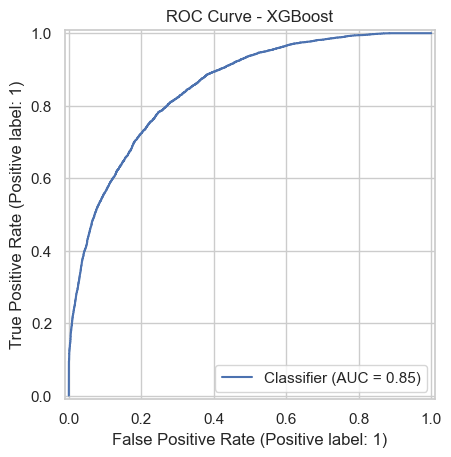

In [151]:
# ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    best_proba
)

plt.title("ROC Curve - XGBoost")
plt.show()

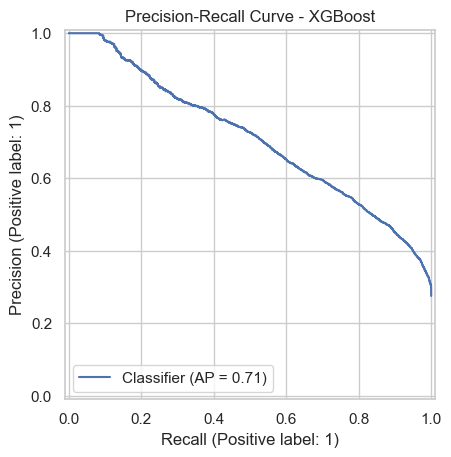

In [152]:
# Precision-recall curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    best_proba
)

plt.title("Precision-Recall Curve - XGBoost")
plt.show()

In [153]:
# Evaluation summary table
best_model_evaluation = pd.DataFrame([xgb_metrics])

best_model_evaluation[metric_cols] = best_model_evaluation[metric_cols].round(3)

best_model_evaluation

NameError: name 'metric_cols' is not defined

<div style="color:#ab9bde;">

### Evaluation Strategy Summary

- XGBoost is selected for detailed evaluation because it achieved the strongest overall performance in the model comparison table.

- The ROC-AUC score shows the model has strong ability to separate cancelled and non-cancelled bookings.

- The Precision-Recall curve is especially important for this project because the cancelled class is the business-critical class. It helps evaluate how well the model performs when focusing on cancellation detection rather than overall accuracy.

- The model shows strong recall for cancellations, meaning it can identify a high share of bookings likely to cancel. However, precision remains moderate, meaning some non-cancelled bookings are also flagged as risky.

- This trade-off will be handled in the next section using threshold optimisation.
</div>

#### <h3 style="color: #ab9bde;">Threshold optimisation</h3>

In [ ]:
# Threshold comparision table
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:
    threshold_pred = (best_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, threshold_pred),
        "precision": precision_score(y_test, threshold_pred),
        "recall": recall_score(y_test, threshold_pred),
        "f1_score": f1_score(y_test, threshold_pred)
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison[["accuracy", "precision", "recall", "f1_score"]] = (
    threshold_comparison[["accuracy", "precision", "recall", "f1_score"]]
    .round(3)
)

threshold_comparison

,threshold,accuracy,precision,recall,f1_score
0,0.30,0.64,0.43,0.93,0.58
1,0.35,0.67,0.45,0.90,0.60
2,0.40,0.70,0.48,0.87,0.62
3,0.45,0.72,0.50,0.84,0.63
4,0.50,0.75,0.53,0.79,0.64
5,0.55,0.78,0.58,0.72,0.64
6,0.60,0.80,0.63,0.64,0.63
7,0.65,0.81,0.67,0.57,0.62
8,0.70,0.81,0.72,0.52,0.60


In [ ]:
best_f1_threshold = threshold_comparison.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

best_f1_threshold

threshold   0.55
accuracy    0.78
precision   0.58
recall      0.72
f1_score    0.64
Name: 5, dtype: float64

In [ ]:
selected_threshold = best_f1_threshold["threshold"]

print(f"Best threshold based on F1-score: {selected_threshold}")

Best threshold based on F1-score: 0.55


In [ ]:
# Predictions with selected threshold
xgb_threshold_pred = (best_proba >= selected_threshold).astype(int)

threshold_cm = confusion_matrix(y_test, xgb_threshold_pred)

threshold_cm_df = pd.DataFrame(
    threshold_cm,
    index=["Actual Not Cancelled", "Actual Cancelled"],
    columns=["Predicted Not Cancelled", "Predicted Cancelled"]
)

threshold_cm_df

,Predicted Not Cancelled,Predicted Cancelled
Actual Not Cancelled,10169,2506
Actual Cancelled,1338,3467


In [ ]:
# Classification report with selected threshold
print(classification_report(y_test, xgb_threshold_pred))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84     12675
           1       0.58      0.72      0.64      4805

    accuracy                           0.78     17480
   macro avg       0.73      0.76      0.74     17480
weighted avg       0.80      0.78      0.79     17480



<div style="color:#ab9bde;">

### Threshold Optimisation Insight

- The threshold comparison shows how the model behaviour changes as the cancellation probability threshold increases.

- At lower thresholds, such as 0.30 and 0.35, the model captures more cancellations, but it also creates many more false cancellation alerts. This gives high recall but low precision.

- At higher thresholds, such as 0.60 and above, the model becomes more conservative. Precision improves, but recall drops because more actual cancellations are missed.

- The best threshold based on F1-score is 0.55.

- Compared with the default threshold of 0.50, the selected threshold of 0.55 reduces false positives and improves precision. This means hotel managers receive fewer unnecessary cancellation-risk alerts.

- However, this comes with a trade-off: recall decreases, meaning the model misses more actual cancellations.

- For a hotel operations use case, the preferred threshold depends on the business goal:

- Use a lower threshold if the hotel wants to catch as many possible cancellations as possible.
- Use a higher threshold if the hotel wants fewer but more reliable risk alerts.
- Use 0.55 as a balanced starting point because it gives the best F1-score in this threshold test.

</div>

 <h3 style="color: #ab9bde;">Feature Importance</h3>

In [ ]:
# Get transformed feature names from the preprocessor

feature_names = preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")
feature_names[:20]

Number of transformed features: 68


array(['numeric__lead_time', 'numeric__arrival_date_year',
       'numeric__arrival_date_week_number',
       'numeric__arrival_date_day_of_month',
       'numeric__stays_in_weekend_nights',
       'numeric__stays_in_week_nights', 'numeric__adults',
       'numeric__children', 'numeric__babies',
       'numeric__previous_cancellations',
       'numeric__previous_bookings_not_canceled',
       'numeric__booking_changes', 'numeric__days_in_waiting_list',
       'numeric__adr', 'numeric__required_car_parking_spaces',
       'numeric__total_of_special_requests', 'numeric__total_nights',
       'numeric__estimated_booking_value',
       'numeric__arrival_month_number',
       'numeric__previous_total_bookings'], dtype=object)

In [ ]:
X_train_preprocessed.shape[1]

68

In [ ]:
# Create feature importance dataframe for XGBoost

xgb_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

xgb_feature_importance.head(20)

,feature,importance
0,binary__room_type_changed,0.14
1,binary__is_last_minute_booking,0.13
2,numeric__required_car_parking_spaces,0.09
3,nominal__market_segment_Online TA,0.06
4,nominal__deposit_type_Non Refund,0.05
5,binary__has_special_requests,0.04
6,numeric__total_of_special_requests,0.04
7,nominal__deposit_type_No Deposit,0.04
8,numeric__previous_cancellation_rate,0.03
9,numeric__lead_time,0.03


In [ ]:
# Clean feature names for readability

xgb_feature_importance["clean_feature"] = (
    xgb_feature_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("nominal__", "", regex=False)
    .str.replace("ordinal__", "", regex=False)
    .str.replace("binary__", "", regex=False)
)

xgb_feature_importance.head(20)

,feature,importance,clean_feature
0,binary__room_type_changed,0.14,room_type_changed
1,binary__is_last_minute_booking,0.13,is_last_minute_booking
2,numeric__required_car_parking_spaces,0.09,required_car_parking_spaces
3,nominal__market_segment_Online TA,0.06,market_segment_Online TA
4,nominal__deposit_type_Non Refund,0.05,deposit_type_Non Refund
5,binary__has_special_requests,0.04,has_special_requests
6,numeric__total_of_special_requests,0.04,total_of_special_requests
7,nominal__deposit_type_No Deposit,0.04,deposit_type_No Deposit
8,numeric__previous_cancellation_rate,0.03,previous_cancellation_rate
9,numeric__lead_time,0.03,lead_time


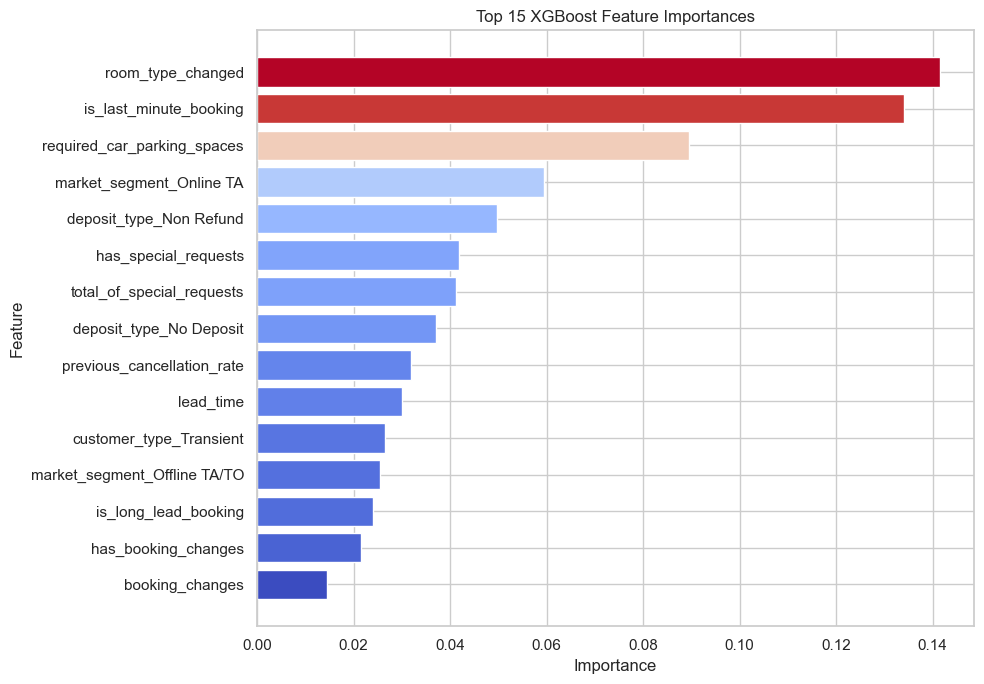

In [ ]:
top_n = 15

top_features = xgb_feature_importance.head(top_n).sort_values(
    by="importance",
    ascending=True
)

# Create coolwarm colors based on importance values
colors = plt.cm.coolwarm(
    (top_features["importance"] - top_features["importance"].min()) /
    (top_features["importance"].max() - top_features["importance"].min())
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["clean_feature"],
    top_features["importance"],
    color=colors
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
xgb_feature_importance.head(20)

,feature,importance,clean_feature
0,binary__room_type_changed,0.14,room_type_changed
1,binary__is_last_minute_booking,0.13,is_last_minute_booking
2,numeric__required_car_parking_spaces,0.09,required_car_parking_spaces
3,nominal__market_segment_Online TA,0.06,market_segment_Online TA
4,nominal__deposit_type_Non Refund,0.05,deposit_type_Non Refund
5,binary__has_special_requests,0.04,has_special_requests
6,numeric__total_of_special_requests,0.04,total_of_special_requests
7,nominal__deposit_type_No Deposit,0.04,deposit_type_No Deposit
8,numeric__previous_cancellation_rate,0.03,previous_cancellation_rate
9,numeric__lead_time,0.03,lead_time


<div style="color:#ab9bde;">

### XGBoost Feature Importance Insight

- The XGBoost feature importance results show that cancellation prediction is strongly influenced by booking structure, timing, deposit behaviour, and guest request patterns.

- The most important feature is `room_type_changed`, suggesting that whether the assigned room differs from the reserved room carries strong predictive value in the model.

- `is_last_minute_booking` is also highly important, showing that booking timing plays a major role in cancellation prediction.

- `required_car_parking_spaces` appears as another strong feature. In practical terms, guests requesting parking may represent more committed bookings, making this feature useful for distinguishing cancellation risk.

- Market channel also matters. `market_segment_Online TA` appears among the top features, indicating that bookings from online travel agencies behave differently from other segments.

- Deposit-related features such as `deposit_type_Non Refund` and `deposit_type_No Deposit` are important, which aligns with the idea that payment commitment affects cancellation behaviour.

- Special request features also appear in the top rankings. Both `has_special_requests` and `total_of_special_requests` are important, suggesting that guests who make specific requests may have different cancellation patterns than guests with no requests.


Overall, the model is not relying on a single variable. It is learning from a combination of:

- booking timing
- room assignment behaviour
- market segment
- deposit type
- guest request behaviour
- previous cancellation history

</div>

 <h3 style="color: #ab9bde;">SHAP</h3>

In [ ]:
pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
try:
    import shap
    print("SHAP imported successfully.")
except ImportError:
    print("SHAP is not installed. Install it using: pip install shap")

SHAP imported successfully.


In [ ]:
# Get transformed feature names from the fitted preprocessor

feature_names = preprocessor.get_feature_names_out()

print(f"Number of feature names: {len(feature_names)}")
print(f"Preprocessed test columns: {X_test_preprocessed.shape[1]}")

Number of feature names: 68
Preprocessed test columns: 68


In [ ]:
# Convert preprocessed test data into a DataFrame for SHAP

X_test_shap = pd.DataFrame(
    X_test_preprocessed,
    columns=feature_names
)

# Clean column names for readability
X_test_shap.columns = (
    X_test_shap.columns
    .str.replace("numeric__", "", regex=False)
    .str.replace("nominal__", "", regex=False)
    .str.replace("ordinal__", "", regex=False)
    .str.replace("binary__", "", regex=False)
)

X_test_shap.head()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights,estimated_booking_value,arrival_month_number,previous_total_bookings,previous_cancellation_rate,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_season_Autumn,arrival_season_Spring,arrival_season_Summer,arrival_season_Winter,lead_time_bucket,adr_bucket,stay_length_category,is_repeated_guest,has_invalid_adr,is_zero_night_stay,is_weekend_stay,is_last_minute_booking,is_long_lead_booking,is_peak_season,has_previous_cancellation,has_previous_successful_booking,has_booking_changes,has_special_requests,is_waitlisted,repeat_guest_with_deposit,repeat_guest_non_refund,is_zero_adr,is_high_adr,is_high_value_booking,room_type_changed
0,1.70,1.00,0.19,-0.75,-0.50,-0.33,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.23,0.00,1.00,-0.67,-0.53,0.20,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,-1.00,-1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,-0.04,1.00,-0.95,0.06,0.50,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.83,0.00,0.00,0.33,0.85,-1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,-1.00,-1.00,2.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
2,1.00,1.00,0.14,0.50,0.00,0.67,0.00,2.00,0.00,0.00,0.00,0.00,0.00,1.87,0.00,1.00,0.67,2.19,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,-1.00,-1.00,2.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
3,-0.04,0.00,0.90,-0.25,0.50,-0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.98,0.00,3.00,0.00,-0.53,0.80,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,-1.00,-1.00,2.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.16,0.00,0.38,0.31,1.50,1.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.59,0.00,0.00,2.33,4.75,0.20,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,-1.00,-1.00,3.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00


In [ ]:
X_test_shap_sample = X_test_shap.sample(
    n=2000,
    random_state=42
)

X_test_shap_sample.shape

(2000, 68)

In [ ]:
# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_shap_sample)

print("SHAP values created successfully.")

SHAP values created successfully.


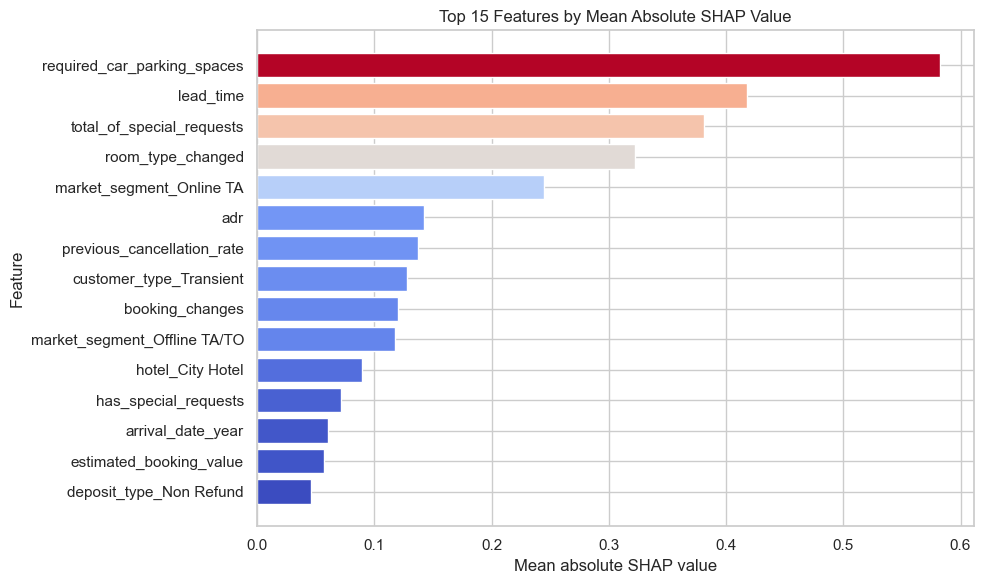

In [ ]:
# Calculate mean absolute SHAP values
shap_importance = pd.DataFrame({
    "feature": X_test_shap_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

# Get top 15 features
top_n = 15

top_shap_features = (
    shap_importance
    .sort_values(by="mean_abs_shap", ascending=False)
    .head(top_n)
    .sort_values(by="mean_abs_shap", ascending=True)
)

# Create coolwarm colors based on SHAP importance
colors = plt.cm.coolwarm(
    (top_shap_features["mean_abs_shap"] - top_shap_features["mean_abs_shap"].min()) /
    (top_shap_features["mean_abs_shap"].max() - top_shap_features["mean_abs_shap"].min())
)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    top_shap_features["feature"],
    top_shap_features["mean_abs_shap"],
    color=colors
)

plt.title("Top 15 Features by Mean Absolute SHAP Value")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

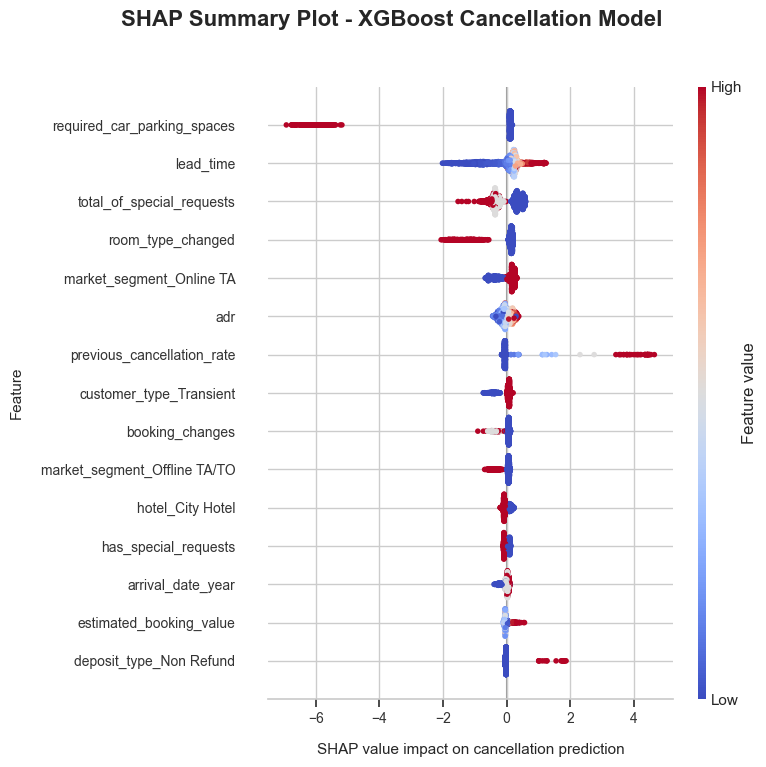

In [ ]:
# More spacious SHAP summary dot plot

plt.figure(figsize=(12, 9))

shap.summary_plot(
    shap_values,
    X_test_shap_sample,
    plot_type="dot",
    max_display=15,
    cmap=plt.cm.coolwarm,
    show=False
)

fig = plt.gcf()
fig.suptitle(
    "SHAP Summary Plot - XGBoost Cancellation Model",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.xlabel(
    "SHAP value impact on cancellation prediction",
    fontsize=11,
    labelpad=12
)

plt.ylabel(
    "Feature",
    fontsize=11,
    labelpad=12
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

<div style="color:#ab9bde;">

### SHAP Direction Insight

The SHAP dot plot explains not only which features are important, but also how they push the model prediction.

`required_car_parking_spaces` is the strongest SHAP driver. Higher values appear mostly on the negative SHAP side, meaning bookings with parking requests generally push the model toward **not cancelled**. This suggests that parking requests may behave like a commitment signal.

`lead_time` is also highly influential. Higher lead-time values tend to push predictions toward **cancelled**, while lower lead-time values tend to push predictions toward **not cancelled**. This matches the business idea that bookings made far in advance may carry more cancellation risk.

`total_of_special_requests` generally pushes predictions toward **not cancelled** when the value is high. This suggests that guests who make more special requests may be more engaged with the booking.

`room_type_changed` has a strong effect and mostly appears on the negative SHAP side when the feature is high. This suggests that room type changes may reduce predicted cancellation risk in this model.

`market_segment_Online TA` tends to push predictions toward **cancelled**, showing that Online Travel Agency bookings are treated as a higher-risk segment by the model.

`previous_cancellation_rate` clearly pushes predictions toward **cancelled** when the value is high. This confirms that previous cancellation behaviour is an important risk signal.

`deposit_type_Non Refund` appears to push predictions toward **cancelled** in this model. This should be interpreted carefully because deposit-related behaviour may reflect hotel policy, booking channel, or customer segment rather than simple guest intention.

Overall, SHAP shows that the model is learning a sensible cancellation-risk pattern from:

- booking timing
- parking request behaviour
- special request behaviour
- room assignment changes
- market segment
- previous cancellation history
- deposit type

</div>

  <h2 style="color: #ab9bde;">Segment-level risk profiling</h2>

In [155]:
# Recreate threshold-based XGBoost predictions

selected_threshold = 0.55

xgb_threshold_pred = (best_proba >= selected_threshold).astype(int)

print(f"Selected threshold: {selected_threshold}")
print(f"Threshold predictions created: {len(xgb_threshold_pred):,}")

Selected threshold: 0.55
Threshold predictions created: 17,480


In [157]:
# Create segment-level profiling dataset from the test set

segment_profile = df.loc[X_test_model.index, [
    "hotel",
    "market_segment",
    "customer_type",
    "estimated_booking_value"
]].copy()

segment_profile["actual_is_cancelled"] = y_test.values
segment_profile["predicted_cancellation_probability"] = best_proba
segment_profile["predicted_is_cancelled"] = xgb_threshold_pred

segment_profile.head()

,hotel,market_segment,customer_type,estimated_booking_value,actual_is_cancelled,predicted_cancellation_probability,predicted_is_cancelled
85803,City Hotel,Online TA,Transient-Party,112.50,0,0.29,0
76338,City Hotel,Online TA,Transient,598.40,0,0.87,1
32698,Resort Hotel,Online TA,Transient,1070.00,0,0.80,1
6989,Resort Hotel,Online TA,Transient,113.40,1,0.57,1
5836,Resort Hotel,Direct,Transient,1971.00,1,0.73,1


In [158]:
# Check shape and columns
print(f"Segment profile rows: {segment_profile.shape[0]:,}")
print(f"Segment profile columns: {segment_profile.shape[1]}")

segment_profile.columns

Segment profile rows: 17,480
Segment profile columns: 7


Index(['hotel', 'market_segment', 'customer_type', 'estimated_booking_value',
       'actual_is_cancelled', 'predicted_cancellation_probability',
       'predicted_is_cancelled'],
      dtype='str')

  <h3 style="color: #ab9bde;">Market segment risk profile</h3>

In [159]:
# Market segment risk
market_segment_risk = (
    segment_profile
    .groupby("market_segment")
    .agg(
        booking_count=("market_segment", "count"),
        actual_cancellation_rate=("actual_is_cancelled", "mean"),
        avg_predicted_cancellation_probability=("predicted_cancellation_probability", "mean"),
        predicted_cancellation_rate=("predicted_is_cancelled", "mean"),
        total_estimated_booking_value=("estimated_booking_value", "sum")
    )
    .reset_index()
)

market_segment_risk["actual_cancellation_rate"] = (
    market_segment_risk["actual_cancellation_rate"] * 100
).round(2)

market_segment_risk["avg_predicted_cancellation_probability"] = (
    market_segment_risk["avg_predicted_cancellation_probability"] * 100
).round(2)

market_segment_risk["predicted_cancellation_rate"] = (
    market_segment_risk["predicted_cancellation_rate"] * 100
).round(2)

market_segment_risk["total_estimated_booking_value"] = (
    market_segment_risk["total_estimated_booking_value"].round(2)
)

market_segment_risk.sort_values(
    by="avg_predicted_cancellation_probability",
    ascending=False
)

,market_segment,booking_count,actual_cancellation_rate,avg_predicted_cancellation_probability,predicted_cancellation_rate,total_estimated_booking_value
6,Online TA,10332,35.06,51.55,50.70,4387008.12
4,Groups,980,28.98,39.50,24.80,246349.53
0,Aviation,46,15.22,34.25,6.52,17323.66
5,Offline TA/TO,2786,14.61,26.93,4.20,1081079.75
3,Direct,2356,15.62,26.86,13.24,949900.48
2,Corporate,842,11.40,21.75,6.41,116748.24
1,Complementary,138,15.22,21.56,4.35,990.00


<div style="color:#ab9bde;">

### Market Segment Risk Insight

The market segment risk profile shows that cancellation risk is not evenly distributed across booking channels.

`Online TA` is the highest-risk and highest-impact segment in the test set. It has the largest booking volume with **10,332 bookings**, the highest actual cancellation rate at **35.06%**, and the highest average predicted cancellation probability at **51.55%**.

This makes Online TA the most important segment for hotel managers to monitor because it combines:

- high booking volume
- high actual cancellation rate
- high predicted cancellation probability
- the largest estimated booking value exposure

`Groups` is the second-highest risk segment based on predicted cancellation probability, with an average predicted risk of **39.50%** and an actual cancellation rate of **28.98%**. However, its total booking volume and estimated value exposure are much smaller than Online TA.

Segments such as `Direct`, `Offline TA/TO`, and `Corporate` show lower predicted cancellation risk. This suggests that these channels may represent more stable booking behaviour compared with Online TA.

Overall, the model identifies `Online TA` as the key segment where cancellation-risk monitoring could provide the greatest operational and revenue benefit. </div>

 <h3 style="color: #ab9bde;">Customer type risk profile  </h3>

In [ ]:
# Customer type risk
customer_type_risk = (
    segment_profile
    .groupby("customer_type")
    .agg(
        booking_count=("customer_type", "count"),
        actual_cancellation_rate=("actual_is_cancelled", "mean"),
        avg_predicted_cancellation_probability=("predicted_cancellation_probability", "mean"),
        predicted_cancellation_rate=("predicted_is_cancelled", "mean"),
        total_estimated_booking_value=("estimated_booking_value", "sum")
    )
    .reset_index()
)

customer_type_risk["actual_cancellation_rate"] = (
    customer_type_risk["actual_cancellation_rate"] * 100
).round(2)

customer_type_risk["avg_predicted_cancellation_probability"] = (
    customer_type_risk["avg_predicted_cancellation_probability"] * 100
).round(2)

customer_type_risk["predicted_cancellation_rate"] = (
    customer_type_risk["predicted_cancellation_rate"] * 100
).round(2)

customer_type_risk["total_estimated_booking_value"] = (
    customer_type_risk["total_estimated_booking_value"].round(2)
)

customer_type_risk.sort_values(
    by="avg_predicted_cancellation_probability",
    ascending=False
)

,customer_type,booking_count,actual_cancellation_rate,avg_predicted_cancellation_probability,predicted_cancellation_rate,total_estimated_booking_value
2,Transient,14401,30.00,45.08,39.62,5765883.90
3,Transient-Party,2362,16.17,27.52,9.36,693623.11
0,Contract,615,14.80,26.98,6.67,317960.78
1,Group,102,11.76,16.71,4.90,21931.99


<div style="color:#ab9bde;">

### Customer Type Risk Insight

The customer type risk profile shows that cancellation risk is concentrated mainly in the `Transient` customer type.

`Transient` customers have the highest booking volume with **14,401 bookings**, the highest actual cancellation rate at **30.00%**, and the highest average predicted cancellation probability at **45.08%**.

This makes `Transient` the most important customer type for cancellation-risk monitoring because it combines:

- the largest booking volume
- the highest actual cancellation rate
- the highest predicted cancellation probability
- the largest estimated booking value exposure

`Transient-Party` and `Contract` customers show moderate predicted cancellation risk, with average predicted cancellation probabilities of **27.52%** and **26.98%** respectively.

`Group` customers show the lowest predicted cancellation risk at **16.71%**, but this segment also has very low booking volume in the test set.

Overall, the model suggests that hotel managers should pay special attention to `Transient` bookings because this customer type carries the largest cancellation-risk and revenue-exposure concentration.

</div>

 <h3 style="color: #ab9bde;">Hotel type risk profile  </h3>

In [161]:
hotel_type_risk = (
    segment_profile
    .groupby("hotel")
    .agg(
        booking_count=("hotel", "count"),
        actual_cancellation_rate=("actual_is_cancelled", "mean"),
        avg_predicted_cancellation_probability=("predicted_cancellation_probability", "mean"),
        predicted_cancellation_rate=("predicted_is_cancelled", "mean"),
        total_estimated_booking_value=("estimated_booking_value", "sum")
    )
    .reset_index()
)

hotel_type_risk["actual_cancellation_rate"] = (
    hotel_type_risk["actual_cancellation_rate"] * 100
).round(2)

hotel_type_risk["avg_predicted_cancellation_probability"] = (
    hotel_type_risk["avg_predicted_cancellation_probability"] * 100
).round(2)

hotel_type_risk["predicted_cancellation_rate"] = (
    hotel_type_risk["predicted_cancellation_rate"] * 100
).round(2)

hotel_type_risk["total_estimated_booking_value"] = (
    hotel_type_risk["total_estimated_booking_value"].round(2)
)

hotel_type_risk.sort_values(
    by="avg_predicted_cancellation_probability",
    ascending=False
)

,hotel,booking_count,actual_cancellation_rate,avg_predicted_cancellation_probability,predicted_cancellation_rate,total_estimated_booking_value
0,City Hotel,10589,30.22,46.08,37.38,3724029.38
1,Resort Hotel,6891,23.29,35.49,29.24,3075370.40


<div style="color:#ab9bde;">

### Hotel Type Risk Insight

The hotel type risk profile shows that `City Hotel` carries higher cancellation risk than `Resort Hotel` in the test set.

`City Hotel` has:

- higher booking volume with **10,589 bookings**
- higher actual cancellation rate at **30.22%**
- higher average predicted cancellation probability at **46.08%**
- higher predicted cancellation rate at **37.38%**
- higher total estimated booking value exposure at **3,724,029.38**

`Resort Hotel` also has meaningful cancellation exposure, but its actual and predicted cancellation risk are lower than City Hotel.

Overall, the model suggests that cancellation-risk monitoring may be especially important for City Hotel bookings because this hotel type combines higher booking volume, higher predicted risk, and higher estimated booking value exposure. </div>

 <h3 style="color: #ab9bde;">  Predicted revenue exposure by market segment  </h3>

In [162]:
# Estimate predicted revenue exposure by market segment

market_segment_revenue_exposure = (
    segment_profile
    .groupby("market_segment")
    .agg(
        booking_count=("market_segment", "count"),
        avg_predicted_cancellation_probability=("predicted_cancellation_probability", "mean"),
        total_estimated_booking_value=("estimated_booking_value", "sum"),
        predicted_at_risk_bookings=("predicted_is_cancelled", "sum")
    )
    .reset_index()
)

market_segment_revenue_exposure["estimated_revenue_at_risk"] = (
    market_segment_revenue_exposure["avg_predicted_cancellation_probability"] *
    market_segment_revenue_exposure["total_estimated_booking_value"]
)

market_segment_revenue_exposure["avg_predicted_cancellation_probability"] = (
    market_segment_revenue_exposure["avg_predicted_cancellation_probability"] * 100
).round(2)

market_segment_revenue_exposure["total_estimated_booking_value"] = (
    market_segment_revenue_exposure["total_estimated_booking_value"].round(2)
)

market_segment_revenue_exposure["estimated_revenue_at_risk"] = (
    market_segment_revenue_exposure["estimated_revenue_at_risk"].round(2)
)

market_segment_revenue_exposure.sort_values(
    by="estimated_revenue_at_risk",
    ascending=False
)

,market_segment,booking_count,avg_predicted_cancellation_probability,total_estimated_booking_value,predicted_at_risk_bookings,estimated_revenue_at_risk
6,Online TA,10332,51.55,4387008.12,5238,2261448.60
5,Offline TA/TO,2786,26.93,1081079.75,117,291119.55
3,Direct,2356,26.86,949900.48,312,255118.49
4,Groups,980,39.50,246349.53,243,97318.18
2,Corporate,842,21.75,116748.24,54,25391.26
0,Aviation,46,34.25,17323.66,3,5932.55
1,Complementary,138,21.56,990.00,6,213.41


<div style="color:#ab9bde;">

### Predicted Revenue Exposure by Market Segment

The predicted revenue exposure table combines cancellation risk with estimated booking value.

This makes the analysis more business-relevant because it does not only show which segments are risky, but also where the largest potential revenue impact is concentrated.

`Online TA` is the dominant revenue-risk segment.

It has:

- the largest booking volume with **10,332 bookings**
- the highest average predicted cancellation probability at **51.55%**
- the largest total estimated booking value at **4,387,008.12**
- the highest number of predicted at-risk bookings with **5,238**
- the highest estimated revenue at risk at **2,261,448.60**

This means that Online TA is not only the highest-risk segment, but also the segment with the largest estimated financial exposure.

`Offline TA/TO` and `Direct` bookings have lower predicted cancellation probabilities, but still show meaningful estimated revenue exposure because of their booking volume and total estimated booking value.

`Groups` has a higher average predicted cancellation probability than Direct and Offline TA/TO, but its estimated revenue at risk is lower because the segment has smaller total booking value.

Overall, this analysis suggests that hotel managers should prioritise cancellation-risk monitoring for `Online TA` bookings first, followed by `Offline TA/TO` and `Direct` bookings from a revenue-protection perspective.

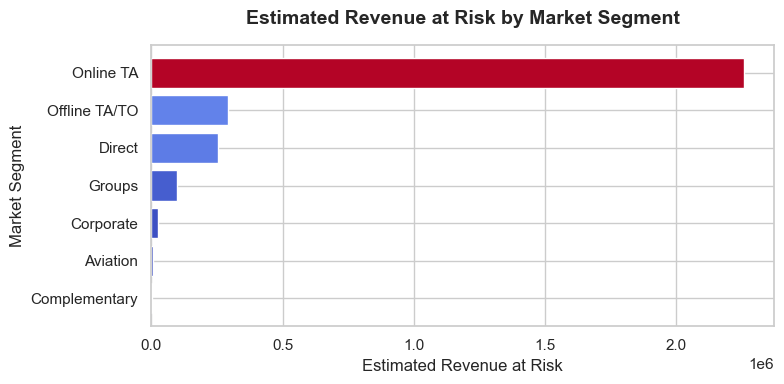

In [165]:
# Create Visual
# Visualise estimated revenue at risk by market segment

plot_data = market_segment_revenue_exposure.sort_values(
    by="estimated_revenue_at_risk",
    ascending=True
)

colors = plt.cm.coolwarm(
    (plot_data["estimated_revenue_at_risk"] - plot_data["estimated_revenue_at_risk"].min()) /
    (plot_data["estimated_revenue_at_risk"].max() - plot_data["estimated_revenue_at_risk"].min())
)

plt.figure(figsize=(8, 4))
plt.barh(
    plot_data["market_segment"],
    plot_data["estimated_revenue_at_risk"],
    color=colors
)

plt.title(
    "Estimated Revenue at Risk by Market Segment",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Estimated Revenue at Risk")
plt.ylabel("Market Segment")

plt.tight_layout()
plt.show()

 <h3 style="color: #ab9bde;"> Save best model & package</h3>

In [168]:


MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Model directory ready: {MODEL_DIR}")

Model directory ready: ../models


In [169]:
best_model_bundle = {
    "model_name": "XGBoost",
    "model": xgb_model,
    "preprocessor": preprocessor,
    "selected_threshold": selected_threshold,
    "model_features": model_features,
    "target_column": target_col
}

best_model_bundle.keys()

dict_keys(['model_name', 'model', 'preprocessor', 'selected_threshold', 'model_features', 'target_column'])

In [170]:
MODEL_PATH = os.path.join(MODEL_DIR, "xgboost_cancellation_model_bundle.joblib")

joblib.dump(best_model_bundle, MODEL_PATH)

print(f"Best model bundle saved successfully at: {MODEL_PATH}")

Best model bundle saved successfully at: ../models/xgboost_cancellation_model_bundle.joblib


In [171]:
loaded_model_bundle = joblib.load(MODEL_PATH)

print("Model bundle loaded successfully.")
print(f"Model name: {loaded_model_bundle['model_name']}")
print(f"Selected threshold: {loaded_model_bundle['selected_threshold']}")
print(f"Number of model features: {len(loaded_model_bundle['model_features'])}")

Model bundle loaded successfully.
Model name: XGBoost
Selected threshold: 0.55
Number of model features: 48


In [172]:
# Test prediction using the loaded model bundle

loaded_model = loaded_model_bundle["model"]
loaded_preprocessor = loaded_model_bundle["preprocessor"]
loaded_threshold = loaded_model_bundle["selected_threshold"]
loaded_features = loaded_model_bundle["model_features"]

sample_booking = X_test_model[loaded_features].head(1)

sample_preprocessed = loaded_preprocessor.transform(sample_booking)

sample_probability = loaded_model.predict_proba(sample_preprocessed)[:, 1][0]

sample_prediction = int(sample_probability >= loaded_threshold)

print(f"Predicted cancellation probability: {sample_probability:.3f}")
print(f"Selected threshold: {loaded_threshold}")
print(f"Predicted cancellation class: {sample_prediction}")

Predicted cancellation probability: 0.292
Selected threshold: 0.55
Predicted cancellation class: 0


<div style="color:#ab9bde;">

### Saved Model Summary

The final XGBoost model bundle was saved successfully.

The bundle includes the trained model, fitted preprocessing transformer, selected threshold, modelling feature list, and target column.

This is important because real-world booking data must go through the same preprocessing steps before prediction.

The saved model was also reloaded and tested on a sample booking, confirming that the saved bundle can be reused for future prediction or deployment.